# Głębokie Uczenie w Praktyce
## Laboratorium 4
### Mateusz Horczak

In [15]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

In [16]:
train_dir = 'train-test-valid/train'
validation_dir = 'train-test-valid/validation'
test_dir = 'train-test-valid/test'

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
test_cats_dir = os.path.join(test_dir, 'cats')
test_dogs_dir = os.path.join(test_dir, 'dogs')

In [20]:
print("Liczba obrazów treningowych kotów:", len(os.listdir(train_cats_dir)))
print("Liczba obrazów treningowych psów:", len(os.listdir(train_dogs_dir)))
print("Liczba obrazów walidacyjnych kotów:", len(os.listdir(validation_cats_dir)))
print("Liczba obrazów walidacyjnych psów:", len(os.listdir(validation_dogs_dir)))
print("Liczba obrazów testowych kotów:", len(os.listdir(test_cats_dir)))
print("Liczba obrazów testowych psów:", len(os.listdir(test_dogs_dir)))

Liczba obrazów treningowych kotów: 1000
Liczba obrazów treningowych psów: 1000
Liczba obrazów walidacyjnych kotów: 500
Liczba obrazów walidacyjnych psów: 500
Liczba obrazów testowych kotów: 500
Liczba obrazów testowych psów: 500


#### Ćwiczenie 1 Tworzenie ImageDataGenerator

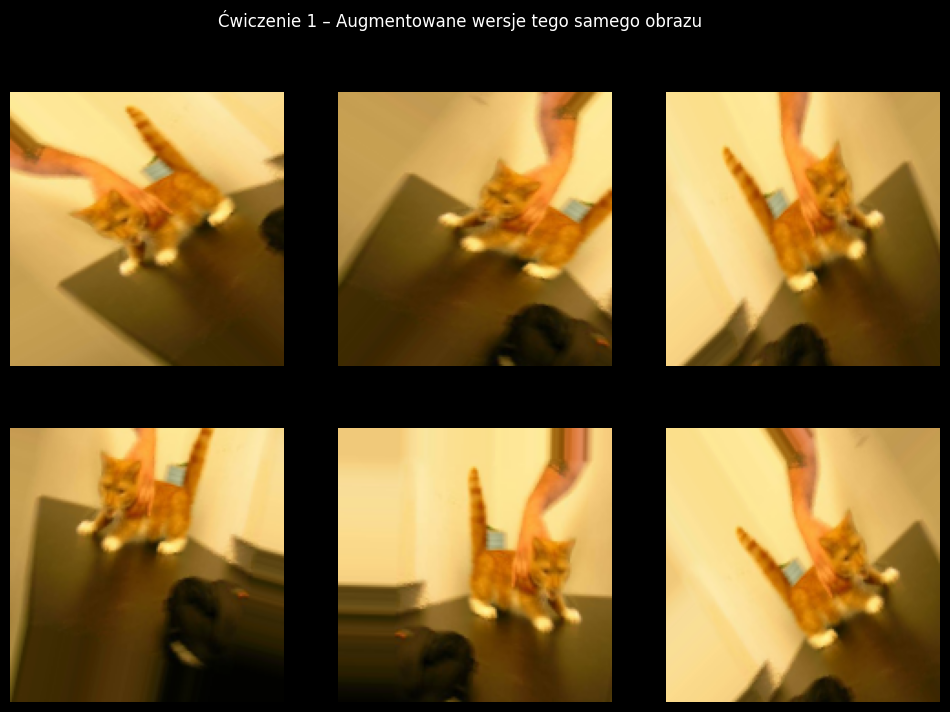

In [18]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

fnames = [os.path.join(train_cats_dir, fname) for fname in os.listdir(train_cats_dir)]
img_path = fnames[0]

img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)

plt.figure(figsize=(12, 8))
for i, batch in enumerate(datagen.flow(x, batch_size=1), 1):
    plt.subplot(2, 3, i)
    plt.imshow(image.array_to_img(batch[0]))
    plt.axis('off')
    if i >= 6:
        break
plt.suptitle('Ćwiczenie 1 – Augmentowane wersje tego samego obrazu')
plt.show()

#### Ćwiczenie 2 Użycie ImageDataGenerator do generacji danych treningowych i walidacyjnych

In [19]:
# z poprzedniego laba
model_aug = models.Sequential()
model_aug.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model_aug.add(layers.MaxPooling2D((2, 2)))
model_aug.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2, 2)))
model_aug.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2, 2)))
model_aug.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2, 2)))
model_aug.add(layers.Flatten())
model_aug.add(layers.Dense(512, activation='relu'))
model_aug.add(layers.Dense(1, activation='sigmoid'))

model_aug.compile(loss='binary_crossentropy',
                  optimizer=optimizers.RMSprop(learning_rate=1e-4),
                  metrics=['acc'])
model_aug.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')
validation_generator = test_datagen.flow_from_directory(
    validation_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

history_aug = model_aug.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/30
 63/100 ━━━━━━━━━━━━━━━━━━━━ 1:07 2s/step - acc: 0.5228 - loss: 0.6952

/home/mateusz/PycharmProjects/glebokie_uczenie_w_praktyce/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - acc: 0.5350 - loss: 0.6915 - val_acc: 0.5000 - val_loss: 0.6939
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 63s 624ms/step - acc: 0.5600 - loss: 0.6825 - val_acc: 0.5830 - val_loss: 0.6694
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 536ms/step - acc: 0.5505 - loss: 0.6773 - val_acc: 0.5650 - val_loss: 0.6764
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 536ms/step - acc: 0.5770 - loss: 0.6692 - val_acc: 0.5370 - val_loss: 0.6858
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 48s 473ms/step - acc: 0.5890 - loss: 0.6627 - val_acc: 0.6130 - val_loss: 0.6441
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 446ms/step - acc: 0.5995 - loss: 0.6584 - val_acc: 0.5290 - val_loss: 0.6761
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 48s 478ms/step - acc: 0.6230 - loss: 0.6445 - val_acc: 0.6030 - val_loss: 0.6593
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 48s 478ms/step - acc: 0.6385 - loss: 0.6250 - val_acc: 0.6680 - val_loss: 0.5995
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 4

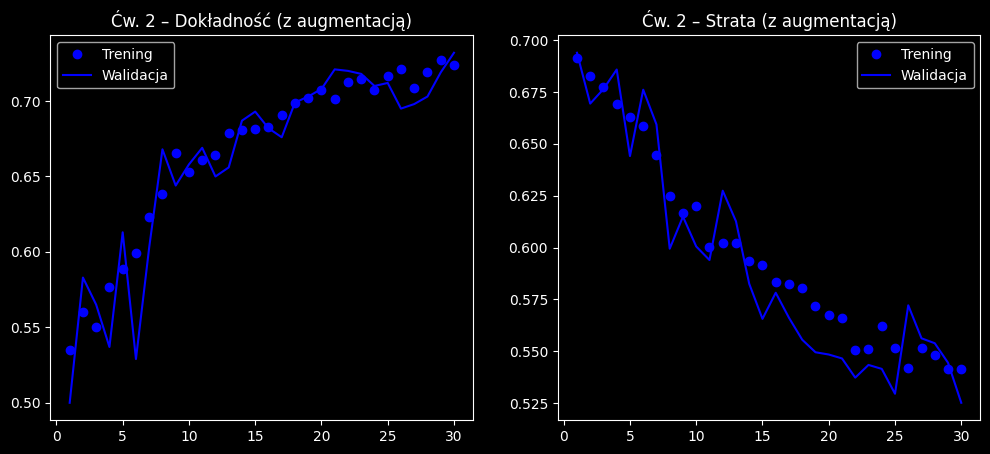

In [8]:
acc = history_aug.history['acc']
val_acc = history_aug.history['val_acc']
loss = history_aug.history['loss']
val_loss = history_aug.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Trening')
plt.plot(epochs, val_acc, 'b', label='Walidacja')
plt.title('Ćw. 2 – Dokładność (z augmentacją)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Trening')
plt.plot(epochs, val_loss, 'b', label='Walidacja')
plt.title('Ćw. 2 – Strata (z augmentacją)')
plt.legend()
plt.show()

#### Ćwiczenie 3 Wpływ warstwy Dropout na dopasowanie modelu (trenowanie bez augumentacji danych)

In [9]:
def create_model(dropout_rate=0.5):
    model = models.Sequential()
    model.add(layers.Input((150, 150, 3)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

In [10]:
train_datagen_noaug = ImageDataGenerator(rescale=1./255)
train_generator_noaug = train_datagen_noaug.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

Found 2000 images belonging to 2 classes.


Trening z Dropout = 0.2 (bez augmentacji)

In [11]:
model_02 = create_model(0.2)
model_02.compile(loss='binary_crossentropy',
                 optimizer=optimizers.RMSprop(learning_rate=1e-4),
                 metrics=['acc'])

history_02 = model_02.fit(
    train_generator_noaug,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 438ms/step - acc: 0.5170 - loss: 0.6931 - val_acc: 0.6050 - val_loss: 0.6891
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 429ms/step - acc: 0.5440 - loss: 0.6840 - val_acc: 0.5250 - val_loss: 0.6881
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 411ms/step - acc: 0.5830 - loss: 0.6773 - val_acc: 0.5940 - val_loss: 0.6677
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 429ms/step - acc: 0.5860 - loss: 0.6640 - val_acc: 0.5920 - val_loss: 0.6600
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 435ms/step - acc: 0.6105 - loss: 0.6575 - val_acc: 0.6100 - val_loss: 0.6462
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 403ms/step - acc: 0.6375 - loss: 0.6448 - val_acc: 0.5770 - val_loss: 0.6779
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 427ms/step - acc: 0.6465 - loss: 0.6365 - val_acc: 0.6060 - val_loss: 0.6419
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 435ms/step - acc: 0.6530 - loss: 0.6201 - val_acc: 0.6550 - val_loss: 0.6152
Epoch 9/30
100/100 ━━━━━━━━━━━━━

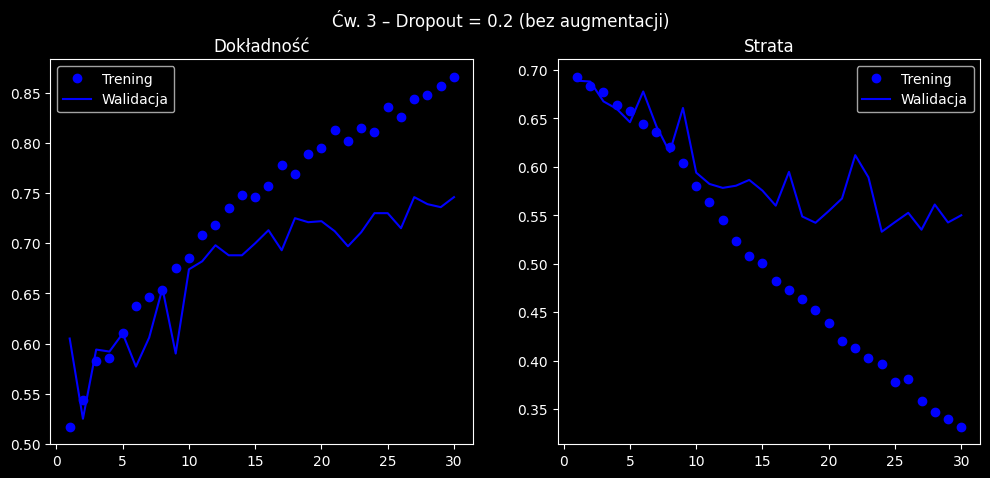

In [12]:
acc = history_02.history['acc']
val_acc = history_02.history['val_acc']
loss = history_02.history['loss']
val_loss = history_02.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.suptitle('Ćw. 3 – Dropout = 0.2 (bez augmentacji)')
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Trening')
plt.plot(epochs, val_acc, 'b', label='Walidacja')
plt.title('Dokładność')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Trening')
plt.plot(epochs, val_loss, 'b', label='Walidacja')
plt.title('Strata')
plt.legend()
plt.show()

Trening z Dropout = 0.5 (bez augmentacji)

In [13]:
model_05 = create_model(0.5)
model_05.compile(loss='binary_crossentropy',
                 optimizer=optimizers.RMSprop(learning_rate=1e-4),
                 metrics=['acc'])

history_05 = model_05.fit(
    train_generator_noaug,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 440ms/step - acc: 0.5075 - loss: 0.6969 - val_acc: 0.5620 - val_loss: 0.6900
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 431ms/step - acc: 0.5215 - loss: 0.6899 - val_acc: 0.5730 - val_loss: 0.6863
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 85s 460ms/step - acc: 0.5555 - loss: 0.6820 - val_acc: 0.5740 - val_loss: 0.6775
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 423ms/step - acc: 0.5640 - loss: 0.6752 - val_acc: 0.5750 - val_loss: 0.6792
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 86s 464ms/step - acc: 0.5900 - loss: 0.6684 - val_acc: 0.5970 - val_loss: 0.6619
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 435ms/step - acc: 0.6085 - loss: 0.6553 - val_acc: 0.5910 - val_loss: 0.6531
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 506ms/step - acc: 0.6160 - loss: 0.6510 - val_acc: 0.6290 - val_loss: 0.6474
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 448ms/step - acc: 0.6140 - loss: 0.6474 - val_acc: 0.6370 - val_loss: 0.6361
Epoch 9/30
100/100 ━━━━━━━━━━━━━

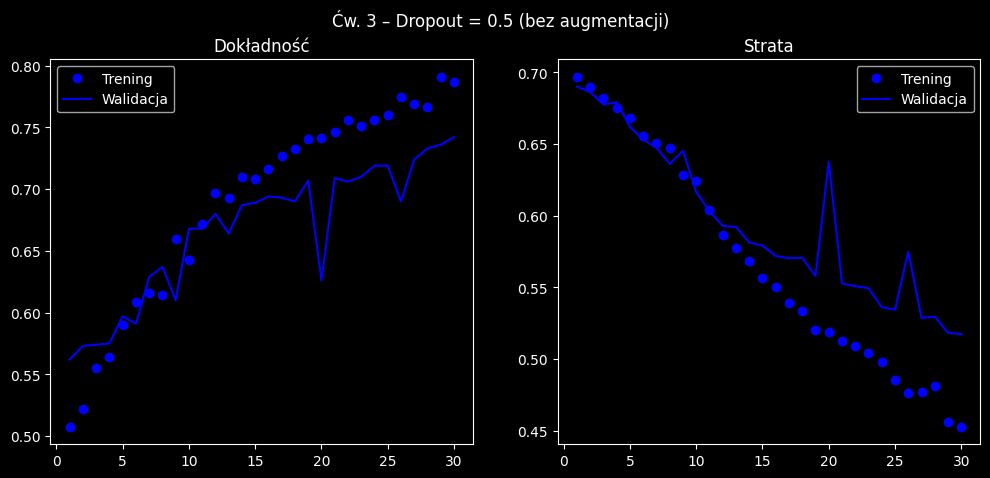

In [14]:
acc = history_05.history['acc']
val_acc = history_05.history['val_acc']
loss = history_05.history['loss']
val_loss = history_05.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.suptitle('Ćw. 3 – Dropout = 0.5 (bez augmentacji)')
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Trening')
plt.plot(epochs, val_acc, 'b', label='Walidacja')
plt.title('Dokładność')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Trening')
plt.plot(epochs, val_loss, 'b', label='Walidacja')
plt.title('Strata')
plt.legend()
plt.show()